# Day 19 — Evolution
### #30DayChartChallenge | April 2026

**Inside the Plastic Boom.** Global plastic production has tripled in just 29 years — from ~130 Mt in 1990 to ~460 Mt in 2019. But "plastic" isn't one material. It's a family of polymers, each with its own chemistry, use case and recycling stream. Polyethylene alone now accounts for nearly a third of everything we make.

**Data:** [Our World in Data](https://ourworldindata.org/grapher/plastic-production-polymer) — *Global primary plastic production by polymer*, based on Geyer et al. (2017) and Plastics Europe + Tecnon OrbiChem  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(tidyr)
library(showtext)
library(sysfonts)
library(scales)
library(ggrepel)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 14, repr.plot.height = 10, repr.plot.res = 300)

In [3]:
# — read & reshape data --------------------------------------------------------
# Source: OWID Global primary plastic production by polymer (1990–2019)

raw <- read.csv("../../data/day_19/plastic_by_polymer.csv",
                stringsAsFactors = FALSE, check.names = FALSE)

long <- raw %>%
  select(-Entity, -Code) %>%
  pivot_longer(-Year, names_to = "polymer_raw", values_to = "tonnes") %>%
  rename(year = Year) %>%
  mutate(mt = tonnes / 1e6)

# Group into 8 categories: 7 named polymer families + Other
polymer_map <- c(
  "HDPE" = "PE", "LLDPE, LLDPE" = "PE",     # polyethylene family
  "PP" = "PP",
  "Fibres" = "Fibres",                         # synthetic textiles
  "PVC" = "PVC",
  "PET" = "PET",
  "PS" = "PS",
  "PUR" = "PUR"
)

long <- long %>%
  mutate(polymer = ifelse(polymer_raw %in% names(polymer_map),
                          polymer_map[polymer_raw], "Other"))

df <- long %>%
  group_by(year, polymer) %>%
  summarise(mt = sum(mt), .groups = "drop")

# Order by 2019 size for stacking (largest at bottom)
order_2019 <- df %>% filter(year == 2019) %>%
  arrange(desc(mt)) %>% pull(polymer)

df <- df %>% mutate(polymer = factor(polymer, levels = order_2019))

# Stats
totals <- df %>% group_by(year) %>% summarise(total = sum(mt), .groups = "drop")
share_2019 <- df %>% filter(year == 2019) %>%
  mutate(pct = mt / sum(mt) * 100) %>%
  arrange(desc(mt))

cat("Production 1990:", round(totals$total[totals$year == 1990]), "Mt\n")
cat("Production 2019:", round(totals$total[totals$year == 2019]), "Mt\n")
cat("Growth:", round(totals$total[totals$year == 2019]/totals$total[totals$year == 1990], 1), "x\n\n")
cat("2019 polymer shares:\n")
print(share_2019)

Production 1990: 130 Mt


Production 2019: 460 Mt


Growth: 3.5 x



2019 polymer shares:


# A tibble: 8 × 4
   year polymer    mt   pct
  <int> <fct>   <dbl> <dbl>
1  2019 PE      110.  23.9 
2  2019 Other   101.  22.0 
3  2019 PP       72.8 15.8 
4  2019 Fibres   60.4 13.1 
5  2019 PVC      51.4 11.2 
6  2019 PET      24.9  5.42
7  2019 PS       21.1  4.59
8  2019 PUR      18.0  3.92


Warning message in annotate("label", x = 1991, y = 410, label = paste0("3.5× growth in 29 years\n", :
"Ignoring unknown parameters: `label.size`"


Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_area()`)."


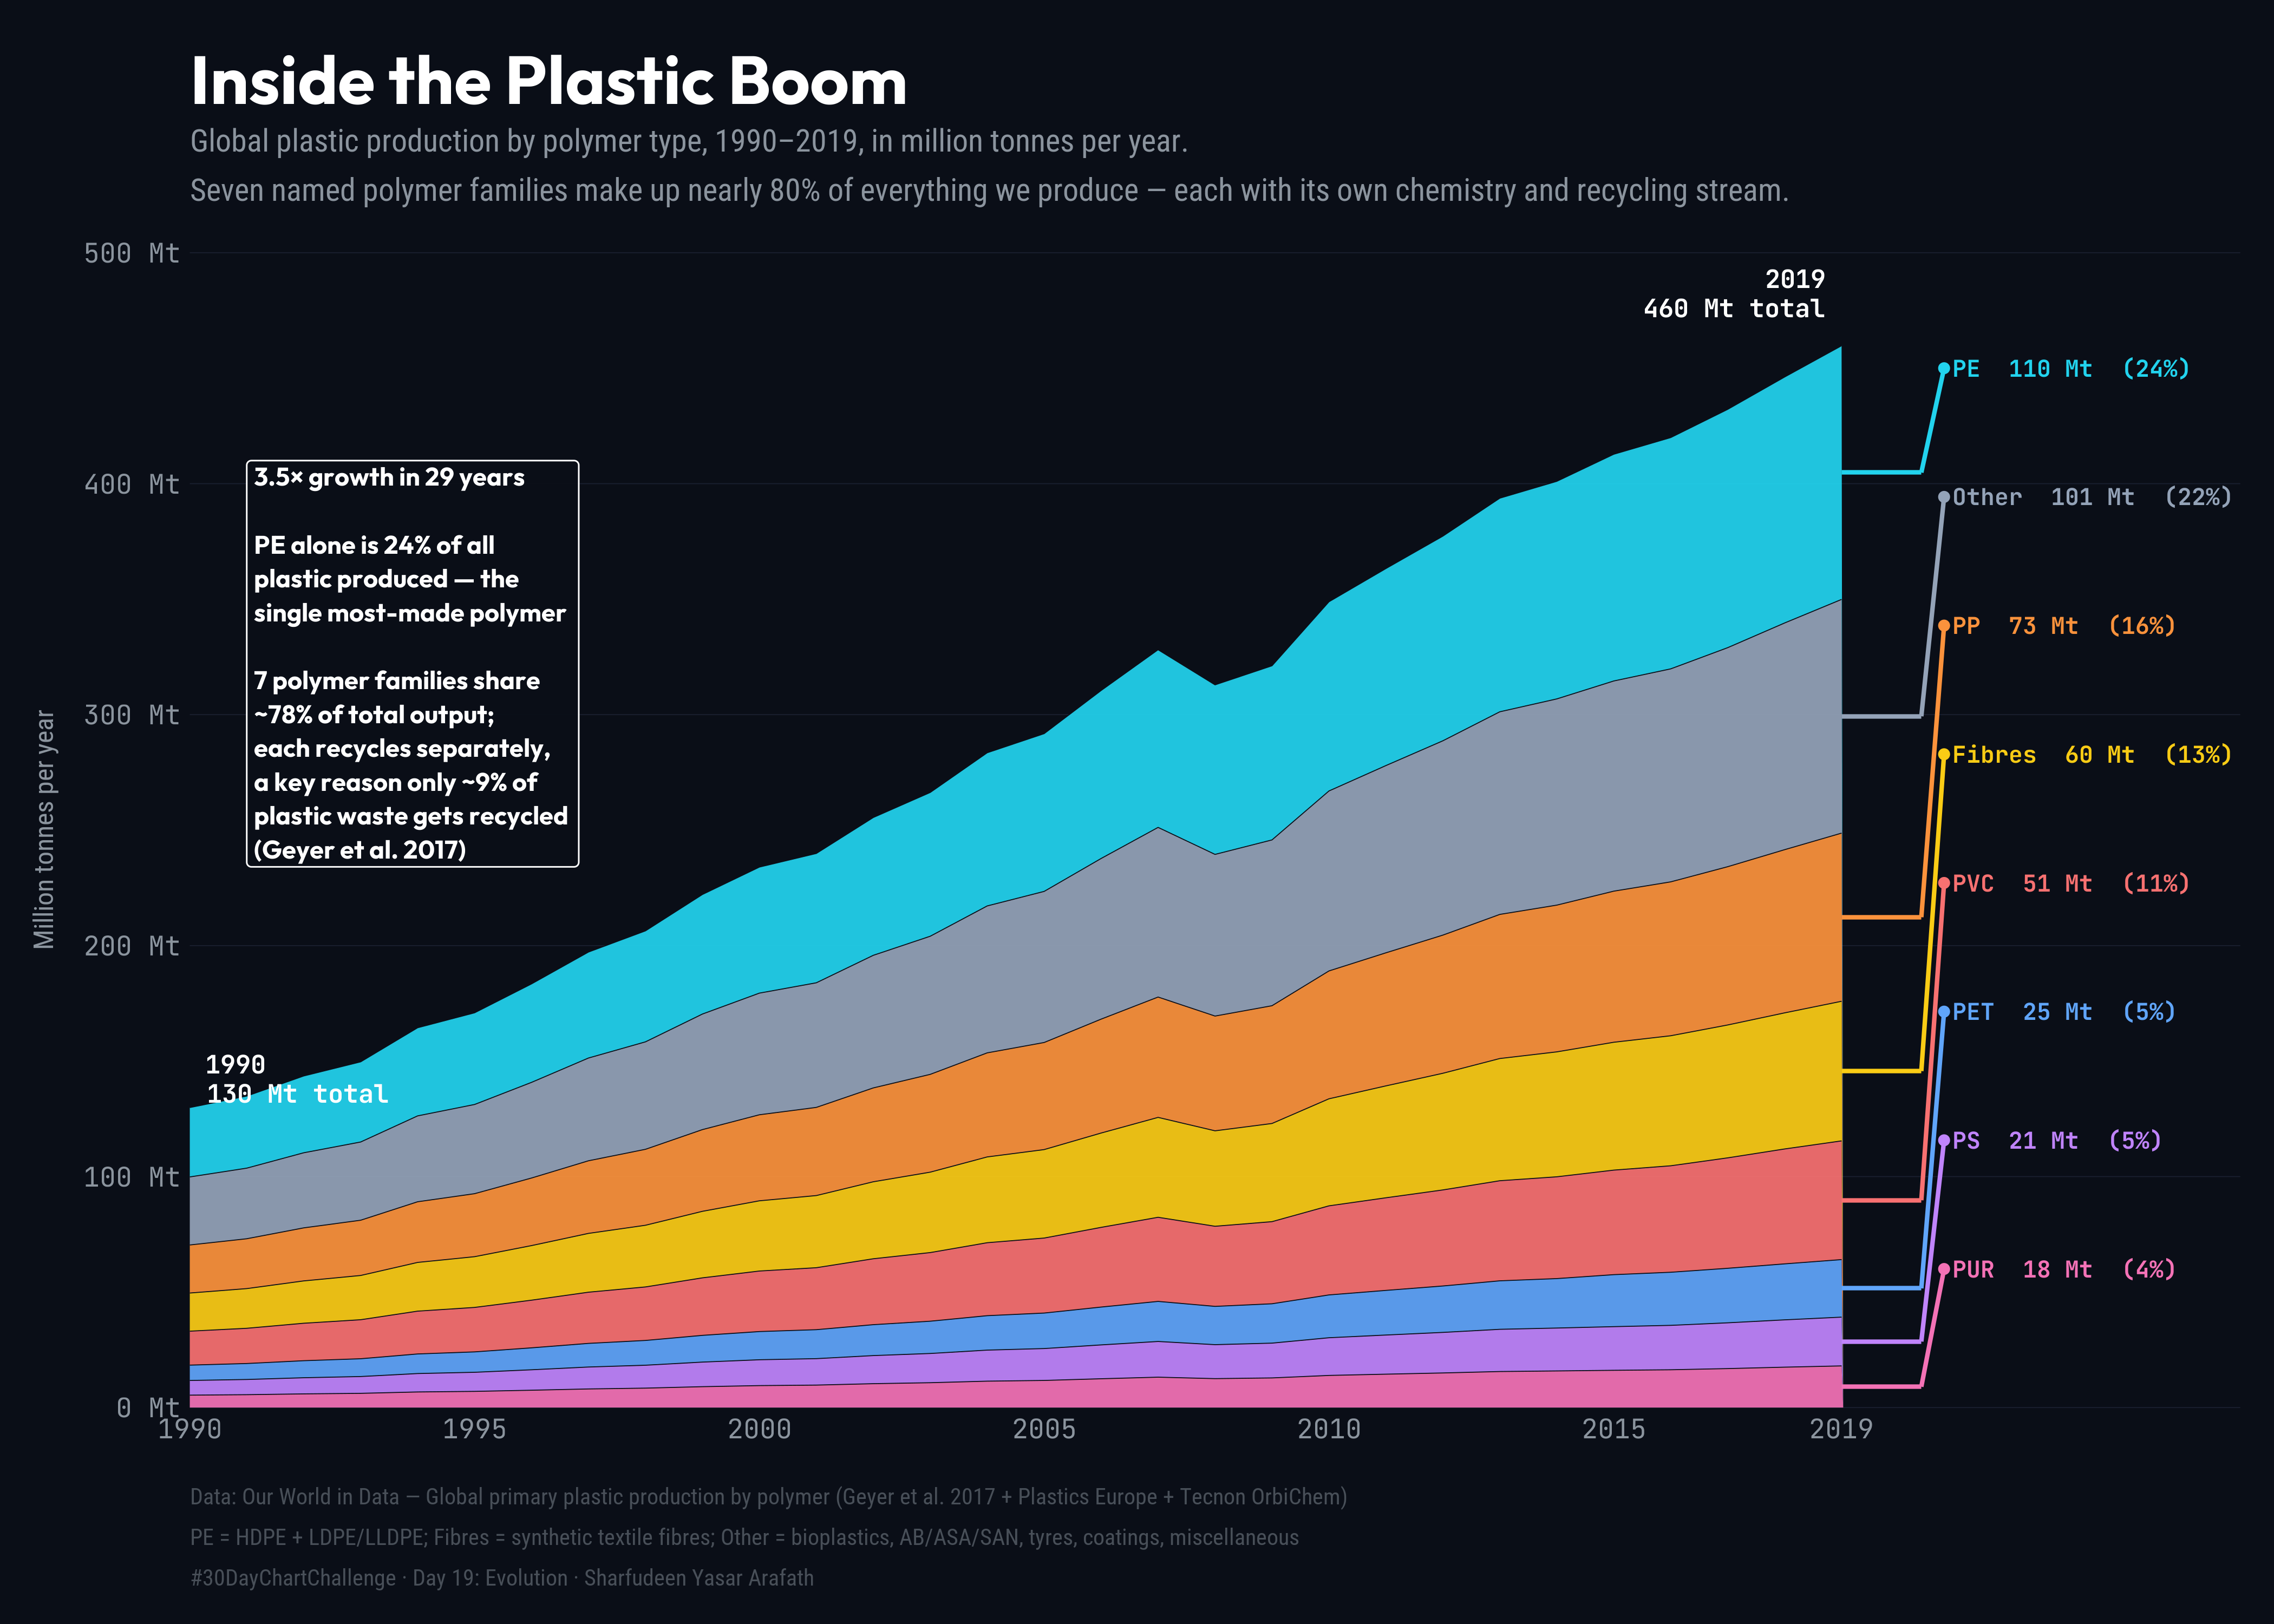

In [4]:
# — build the plot ------------------------------------------------------------

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"; grid_col <- "#1a2030"

# Distinct polymer palette (works on dark bg)
pal <- c(
  "PE"     = "#22d3ee",  # cyan
  "PP"     = "#fb923c",  # orange
  "Fibres" = "#facc15",  # yellow
  "Other"  = "#94a3b8",  # gray
  "PVC"    = "#f87171",  # red
  "PET"    = "#60a5fa",  # blue
  "PUR"    = "#f472b6",  # pink
  "PS"     = "#c084fc"   # purple
)

# geom_area() stacks these fills in reverse factor order,
# so compute band midpoints from the bottom band upward first.
labels_2019 <- df %>% filter(year == 2019) %>%
  arrange(desc(polymer)) %>%                        # bottom band to top band
  mutate(ymin = lag(cumsum(mt), default = 0),
         band_mid = ymin + mt/2) %>%               # midpoint of each visible band
  arrange(desc(band_mid)) %>%                       # top band to bottom band
  mutate(label_y = seq(450, 60, length.out = n()),  # evenly spaced label column
         pct = round(mt / sum(mt) * 100),
         label = paste0(polymer, "  ", round(mt), " Mt  (", pct, "%)"))

# Elbow leader line: horizontal from band edge → vertical/diagonal to label
elbow_x1 <- 2019      # band right edge
elbow_x2 <- 2020.4    # turn point
elbow_x3 <- 2020.8    # label start

p <- ggplot(df, aes(x = year, y = mt, fill = polymer)) +
  geom_area(alpha = 0.92, color = bg, linewidth = 0.15) +

  # Leader segment 1: horizontal from band midpoint
  geom_segment(data = labels_2019,
               aes(x = elbow_x1, xend = elbow_x2,
                   y = band_mid, yend = band_mid,
                   color = polymer),
               linewidth = 0.7, show.legend = FALSE) +

  # Leader segment 2: diagonal from turn point to label y
  geom_segment(data = labels_2019,
               aes(x = elbow_x2, xend = elbow_x3,
                   y = band_mid, yend = label_y,
                   color = polymer),
               linewidth = 0.7, show.legend = FALSE) +

  # Small dot at label end of each leader
  geom_point(data = labels_2019,
             aes(x = elbow_x3, y = label_y, color = polymer),
             size = 1.6, show.legend = FALSE) +

  # Polymer label text in ranked column
  geom_text(data = labels_2019,
            aes(x = elbow_x3 + 0.15, y = label_y,
                label = label, color = polymer),
            hjust = 0, family = "jetbrains", size = 3.6,
            fontface = "bold", show.legend = FALSE) +

  # Total-line annotation: top of stack at 1990 and 2019
  annotate("text", x = 1990.3, y = 132,
    label = "1990\n130 Mt total",
    family = "jetbrains", fontface = "bold", size = 4,
    color = "#FFFFFF", hjust = 0, vjust = 0, lineheight = 0.95) +
  annotate("text", x = 2018.7, y = 472,
    label = "2019\n460 Mt total",
    family = "jetbrains", fontface = "bold", size = 4,
    color = "#FFFFFF", hjust = 1, vjust = 0, lineheight = 0.95) +

  # Big takeaway callout (top-left empty area)
  annotate("label", x = 1991, y = 410,
    label = paste0(
      "3.5\u00d7 growth in 29 years\n",
      "\n",
      "PE alone is 24% of all\n",
      "plastic produced \u2014 the\n",
      "single most-made polymer\n",
      "\n",
      "7 polymer families share\n",
      "~78% of total output;\n",
      "each recycles separately,\n",
      "a key reason only ~9% of\n",
      "plastic waste gets recycled\n",
      "(Geyer et al. 2017)"),
    family = "outfit", fontface = "bold", size = 4,
    color = "#FFFFFF", fill = "#0a0e17EE", label.size = 0,
    lineheight = 1.1, hjust = 0, vjust = 1) +

  scale_fill_manual(values = pal, guide = "none") +
  scale_color_manual(values = pal, guide = "none") +
  scale_x_continuous(
    breaks = c(1990, 1995, 2000, 2005, 2010, 2015, 2019),
    limits = c(1990, 2026),
    expand = c(0, 0)) +
  scale_y_continuous(
    breaks = seq(0, 500, 100),
    labels = function(x) paste0(x, " Mt"),
    limits = c(0, 500),
    expand = c(0, 0)) +
  coord_cartesian(clip = "off") +

  labs(
    title = "Inside the Plastic Boom",
    subtitle = paste0(
      "Global plastic production by polymer type, 1990\u20132019, in million tonnes per year.\n",
      "Seven named polymer families make up nearly 80% of everything we produce \u2014 each with its own chemistry and recycling stream."
    ),
    x = NULL,
    y = "Million tonnes per year",
    caption = paste0(
      "Data: Our World in Data \u2014 Global primary plastic production by polymer (Geyer et al. 2017 + Plastics Europe + Tecnon OrbiChem)\n",
      "PE = HDPE + LDPE/LLDPE; Fibres = synthetic textile fibres; Other = bioplastics, AB/ASA/SAN, tyres, coatings, miscellaneous\n",
      "#30DayChartChallenge \u00b7 Day 19: Evolution \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 30,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 14, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 20)),
    plot.caption = element_text(size = 10, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 20)),
    axis.text = element_text(size = 12, color = txt_dim,
      family = "jetbrains"),
    axis.title.y = element_text(size = 12, color = txt_dim,
      margin = margin(r = 10)),
    panel.grid.major.y = element_line(color = grid_col, linewidth = 0.15),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 15, 15, 15)
  )

p

In [5]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_19_evolution.png",
       plot = p, width = 14, height = 10, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_19_evolution.png\n")

Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_area()`)."


Done — saved to chart/day_19_evolution.png
